# 스프린트 미션 13 — 신용카드 고객 세그먼테이션

**제출 파일명:** `미션13_팀명_성함.ipynb`  
**분석 목표:** EDA → 전처리 비교 → 차원축소 → 알고리즘 비교 → 안정성 검증 → 세그먼트 해석 → 마케팅 전략

이 노트북은 Google Colab에서 위에서 아래로 실행할 수 있습니다. 첫 실행 시 `credit_card.csv`를 업로드하면 됩니다.

> 분석 원칙: 실루엣 최대값만 고르지 않고 군집 크기 균형, 재표본 안정성, 비즈니스 실행 가능성을 함께 평가합니다.

In [1]:
# Colab/로컬 공통 패키지 준비
import importlib.util, sys
required = ['pandas', 'numpy', 'sklearn', 'matplotlib', 'seaborn', 'scipy', 'joblib']
if any(importlib.util.find_spec(m) is None for m in required):
    get_ipython().run_line_magic('pip', '-q install pandas numpy scipy scikit-learn matplotlib seaborn joblib')

In [2]:
from pathlib import Path
import os, sys, warnings, json
warnings.filterwarnings('ignore')
os.environ.setdefault('OMP_NUM_THREADS', '4')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans, Birch
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, RobustScaler
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['axes.unicode_minus'] = False
# Colab에서 한글 글꼴이 없으면 그래프 라벨은 영문 변수명을 사용해도 분석에는 영향이 없습니다.
for candidate in ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        plt.rcParams['font.family'] = candidate
        break
    except Exception:
        pass

LOG_COLS = ['BALANCE','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES',
            'CASH_ADVANCE','CASH_ADVANCE_TRX','PURCHASES_TRX','CREDIT_LIMIT',
            'PAYMENTS','MINIMUM_PAYMENTS']

## 1. 데이터 로드와 무결성 점검

In [3]:
def load_credit_card_data():
    candidates = [Path('/content/credit_card.csv'), Path('credit_card.csv'),
                  Path('work/credit_card.csv'), Path('../work/credit_card.csv')]
    for p in candidates:
        if p.exists():
            print(f'Loaded: {p.resolve()}')
            return pd.read_csv(p)
    try:
        from google.colab import files
        uploaded = files.upload()
        name = next(iter(uploaded))
        return pd.read_csv(name)
    except Exception as e:
        raise FileNotFoundError('credit_card.csv를 Colab에 업로드하거나 현재 폴더에 두세요.') from e

df = load_credit_card_data()
print('shape:', df.shape)
display(df.head())

Loaded: C:\Users\lucy5\Documents\Codex\2026-09-14\13-1-eda-2-k-means\work\credit_card.csv
shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_n': df.isna().sum(),
    'missing_rate': df.isna().mean(),
    'unique_n': df.nunique(dropna=False),
    'zero_rate': [(df[c].eq(0).mean() if pd.api.types.is_numeric_dtype(df[c]) else np.nan) for c in df.columns]
})
print('완전 중복 행:', df.duplicated().sum())
print('CUST_ID 중복:', df['CUST_ID'].duplicated().sum())
display(audit)

완전 중복 행: 0
CUST_ID 중복: 0


,dtype,missing_n,missing_rate,unique_n,zero_rate
CUST_ID,str,0,0.000000,8950,NaN
BALANCE,float64,0,0.000000,8871,0.008939
BALANCE_FREQUENCY,float64,0,0.000000,43,0.008939
PURCHASES,float64,0,0.000000,6203,0.228380
ONEOFF_PURCHASES,float64,0,0.000000,4014,0.480670
INSTALLMENTS_PURCHASES,float64,0,0.000000,4452,0.437542
CASH_ADVANCE,float64,0,0.000000,4323,0.517095
PURCHASES_FREQUENCY,float64,0,0.000000,47,0.228268
ONEOFF_PURCHASES_FREQUENCY,float64,0,0.000000,47,0.480670
PURCHASES_INSTALLMENTS_FREQUENCY,float64,0,0.000000,47,0.437430


결측은 `MINIMUM_PAYMENTS`와 `CREDIT_LIMIT`에만 존재합니다. 고객 삭제는 특정 상환행동 집단을 체계적으로 제외할 수 있으므로 중앙값 대체를 사용합니다. `CUST_ID`는 식별자이므로 모델 입력에서 제외합니다.

## 2. EDA — 분포, 0 비율, 상관 구조

In [5]:
features = [c for c in df.columns if c != 'CUST_ID']
desc = df[features].describe(percentiles=[.01,.25,.5,.75,.99]).T
desc['skew'] = df[features].skew()
desc['zero_rate'] = (df[features] == 0).mean()
desc['missing_rate'] = df[features].isna().mean()
display(desc.sort_values('skew', ascending=False))

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,zero_rate,missing_rate
MINIMUM_PAYMENTS,8637.0,864.206542,2372.446607,0.019163,19.524478,169.123707,312.343947,825.485459,9034.098737,76406.20752,13.622797,0.000000,0.034972
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,0.000000,38.000000,577.405000,6689.898200,40761.25000,10.045083,0.480670,0.000000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,0.000000,39.635000,361.280000,1110.130000,8977.290000,49039.57000,8.144269,0.228380,0.000000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,0.000000,89.000000,468.637500,3886.240500,22500.00000,7.299120,0.437542,0.000000
PAYMENTS,8950.0,1733.143852,2895.063757,0.000000,0.000000,383.276166,856.901546,1901.134317,13608.715541,50721.48336,5.907620,0.026816,0.000000
CASH_ADVANCE_TRX,8950.0,3.248827,6.824647,0.000000,0.000000,0.000000,0.000000,4.000000,29.000000,123.00000,5.721298,0.517095,0.000000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,0.000000,1113.821139,9588.163357,47137.21176,5.166609,0.517095,0.000000
PURCHASES_TRX,8950.0,14.709832,24.857649,0.000000,0.000000,1.000000,7.000000,17.000000,116.510000,358.00000,4.630655,0.228380,0.000000
BALANCE,8950.0,1564.474828,2081.531879,0.000000,0.065101,128.281915,873.385231,2054.140036,9338.804814,19043.13856,2.393386,0.008939,0.000000
PRC_FULL_PAYMENT,8950.0,0.153715,0.292499,0.000000,0.000000,0.000000,0.000000,0.142857,1.000000,1.00000,1.942820,0.659553,0.000000


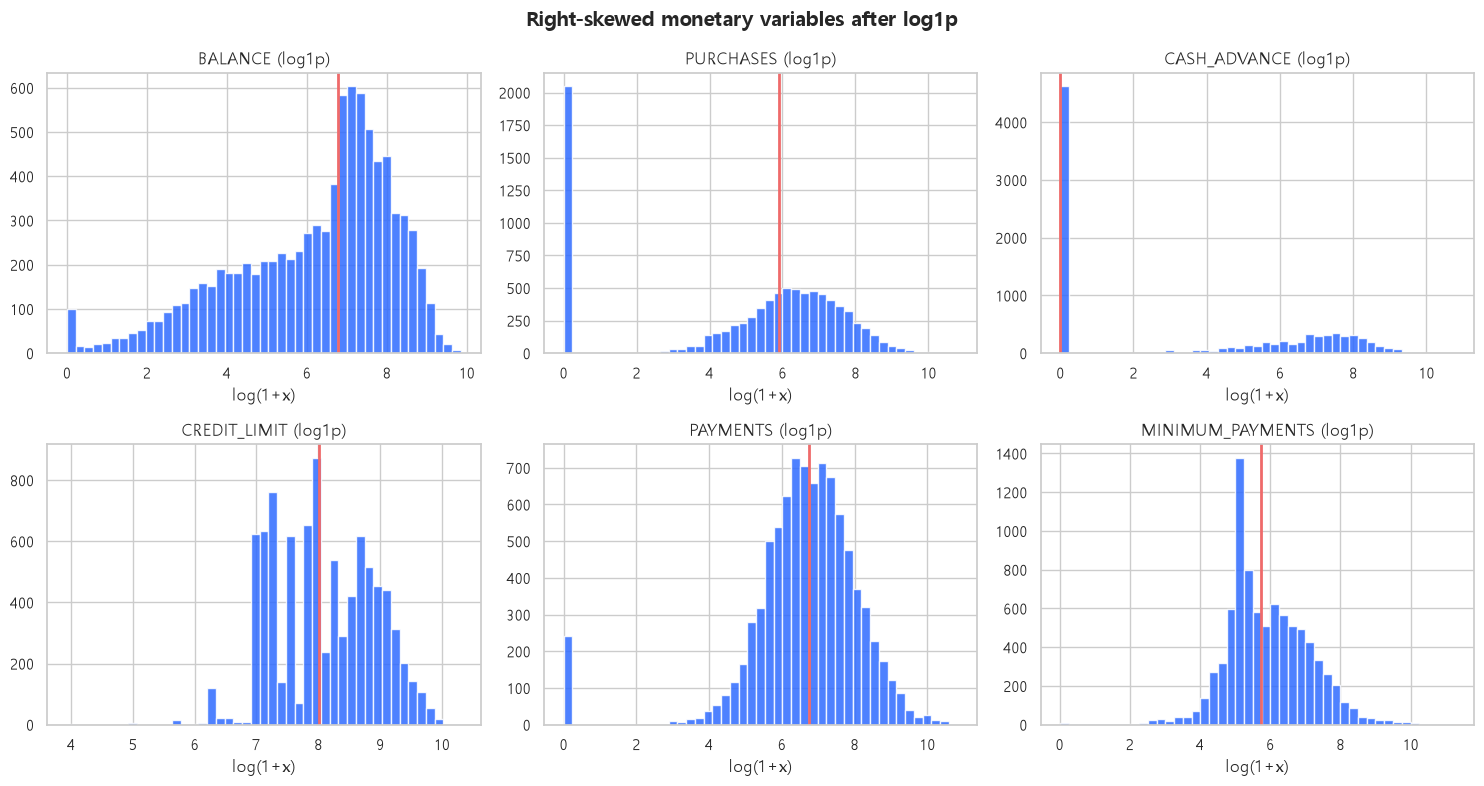

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
selected = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS']
for ax, col in zip(axes.ravel(), selected):
    x = df[col].dropna()
    ax.hist(np.log1p(x), bins=45, color='#2F6BFF', alpha=.85)
    ax.axvline(np.log1p(x.median()), color='#EF6A6A', lw=2)
    ax.set_title(f'{col} (log1p)')
    ax.set_xlabel('log(1+x)')
plt.suptitle('Right-skewed monetary variables after log1p', fontweight='bold')
plt.tight_layout(); plt.show()

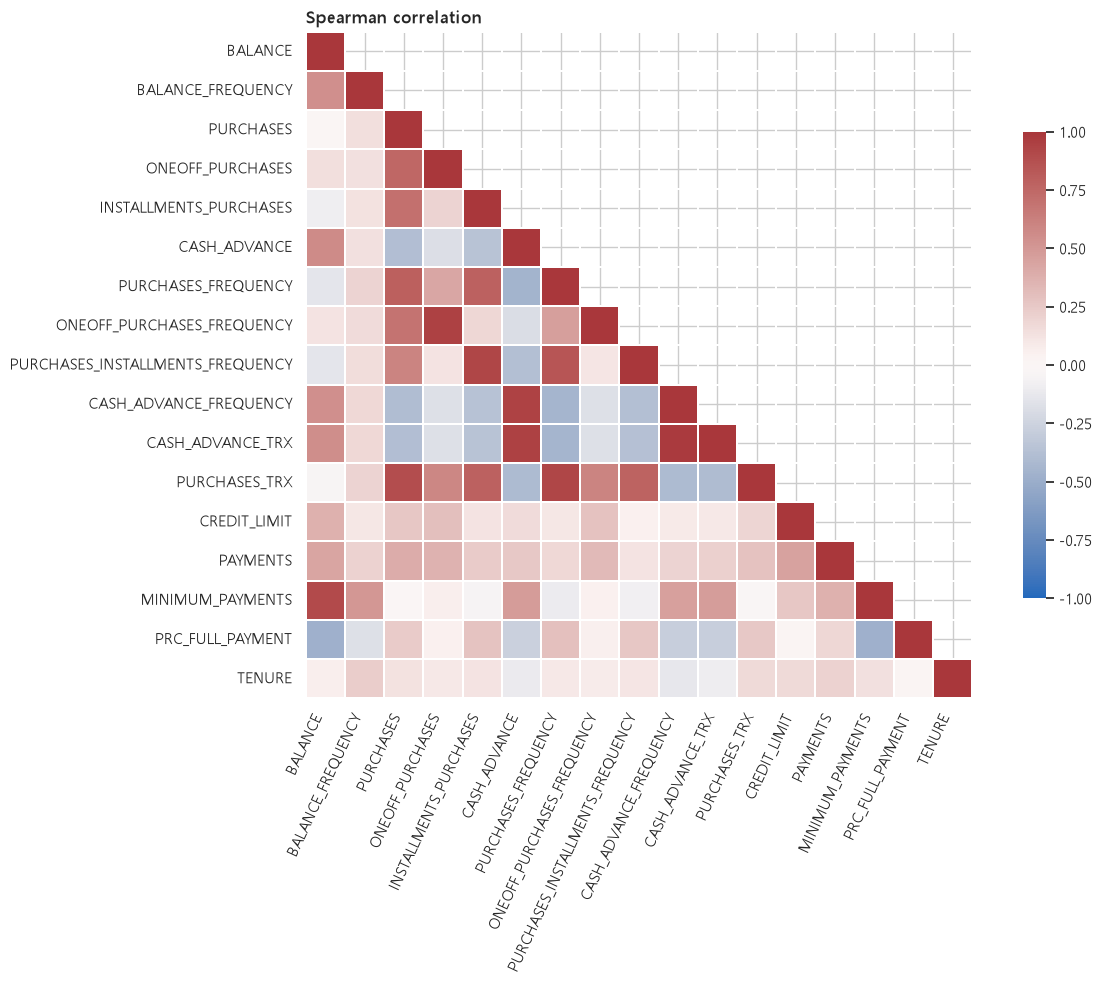

In [7]:
corr = df[features].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), 1)
plt.figure(figsize=(13, 10))
sns.heatmap(corr, mask=mask, cmap='vlag', center=0, vmin=-1, vmax=1,
            square=True, linewidths=.3, cbar_kws={'shrink':.7})
plt.title('Spearman correlation', loc='left', fontweight='bold')
plt.xticks(rotation=65, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

**EDA 결론**

- 금액·거래횟수 변수는 오른쪽 꼬리가 매우 길어 원거리 극단값이 k-means 중심을 끌어당길 수 있습니다.
- 구매·현금서비스 관련 변수의 0은 “행동 없음”이라는 신호이므로 보존합니다.
- 구매 금액·횟수·빈도 변수군은 상관이 높아 중복 가중 가능성이 있습니다. PCA로 상관 구조를 압축합니다.

## 3. 전처리 조합 비교

In [8]:
def preprocess(df, method):
    features = [c for c in df.columns if c != 'CUST_ID']
    imputer = SimpleImputer(strategy='median')
    Xi = pd.DataFrame(imputer.fit_transform(df[features]), columns=features, index=df.index)
    Xt = Xi.copy()
    if 'winsor' in method:
        Xt = Xt.clip(Xt.quantile(.01), Xt.quantile(.99), axis=1)
    if 'log' in method:
        Xt[LOG_COLS] = np.log1p(Xt[LOG_COLS])
    scaler = RobustScaler() if 'robust' in method else StandardScaler()
    Xs = scaler.fit_transform(Xt)
    pca = None
    if 'pca90' in method:
        pca = PCA(n_components=.90, random_state=RANDOM_STATE)
        Xs = pca.fit_transform(Xs)
    elif 'pca95' in method:
        pca = PCA(n_components=.95, random_state=RANDOM_STATE)
        Xs = pca.fit_transform(Xs)
    return Xi, Xt, Xs, imputer, scaler, pca

def cluster_metrics(X, labels):
    counts = pd.Series(labels).value_counts()
    return {
        'silhouette': silhouette_score(X, labels, sample_size=min(4000, len(X)), random_state=RANDOM_STATE),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels),
        'min_share': counts.min()/len(labels),
        'max_share': counts.max()/len(labels),
    }

methods = ['raw_standard','winsor_standard','log_standard','log_robust',
           'log_standard_pca90','log_robust_pca90','log_robust_pca95']
method_labels = {
    'raw_standard':'raw+standard', 'winsor_standard':'winsor+standard',
    'log_standard':'log+standard', 'log_robust':'log+robust',
    'log_standard_pca90':'log+standard+PCA90',
    'log_robust_pca90':'log+robust+PCA90',
    'log_robust_pca95':'log+robust+PCA95'}

rows, cache = [], {}
for method in methods:
    package = preprocess(df, method)
    cache[method] = package
    X = package[2]
    pca_obj = package[-1]
    for k in range(2, 11):
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE,
                        n_init=30, max_iter=500).fit_predict(X)
        rows.append({'method':method, 'label':method_labels[method], 'k':k,
                     'pca_n': pca_obj.n_components_ if pca_obj is not None else np.nan,
                     **cluster_metrics(X, labels)})
kmeans_grid = pd.DataFrame(rows)
display(kmeans_grid.sort_values('silhouette', ascending=False).head(15))

,method,label,k,pca_n,silhouette,calinski_harabasz,davies_bouldin,min_share,max_share
46,log_robust_pca90,log+robust+PCA90,3,6.0,0.435256,4208.921975,0.960125,0.138436,0.715307
55,log_robust_pca95,log+robust+PCA95,3,8.0,0.409854,3782.249035,1.016433,0.138883,0.715419
28,log_robust,log+robust,3,NaN,0.390788,3511.255589,1.062225,0.138547,0.715419
45,log_robust_pca90,log+robust+PCA90,2,6.0,0.387291,3441.606989,1.488934,0.278212,0.721788
54,log_robust_pca95,log+robust+PCA95,2,8.0,0.365355,3184.028091,1.547091,0.277877,0.722123
27,log_robust,log+robust,2,NaN,0.349287,3013.149505,1.594664,0.277877,0.722123
48,log_robust_pca90,log+robust+PCA90,5,6.0,0.321799,4055.437445,1.015817,0.066369,0.419106
47,log_robust_pca90,log+robust+PCA90,4,6.0,0.306284,4072.534514,1.144100,0.132961,0.440559
50,log_robust_pca90,log+robust+PCA90,7,6.0,0.306209,3705.789526,1.155645,0.044134,0.259218
9,winsor_standard,winsor+standard,2,NaN,0.305193,2054.200185,1.637586,0.184134,0.815866


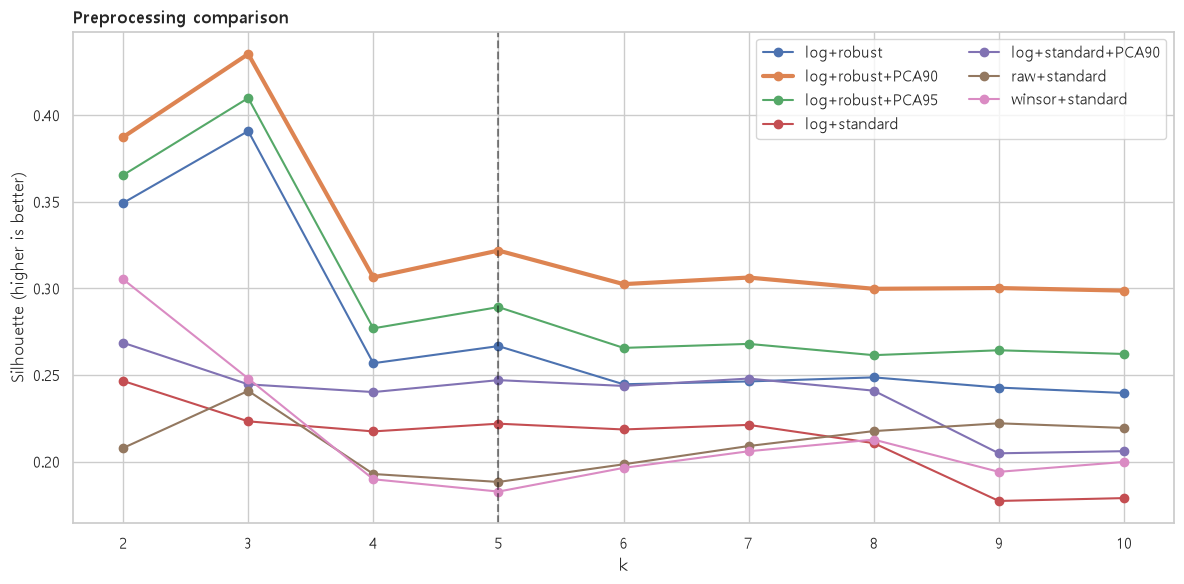

In [9]:
plt.figure(figsize=(12, 6))
for label, g in kmeans_grid.groupby('label'):
    lw = 3 if label == 'log+robust+PCA90' else 1.5
    plt.plot(g['k'], g['silhouette'], marker='o', lw=lw, label=label)
plt.axvline(5, color='black', ls='--', alpha=.45)
plt.xlabel('k'); plt.ylabel('Silhouette (higher is better)')
plt.title('Preprocessing comparison', loc='left', fontweight='bold')
plt.xticks(range(2,11)); plt.legend(ncol=2)
plt.tight_layout(); plt.show()

최종 전처리는 `log1p → RobustScaler → PCA(90%)`입니다. 원본 표준화 k=5보다 실루엣이 크게 개선되며, PCA 95%보다 90%가 더 나은 결과를 보여 저설명력 축의 잡음을 억제합니다.

## 4. k와 알고리즘 비교

,k,silhouette,calinski_harabasz,davies_bouldin,min_share,max_share
45,2,0.387291,3441.606989,1.488934,0.278212,0.721788
46,3,0.435256,4208.921975,0.960125,0.138436,0.715307
47,4,0.306284,4072.534514,1.144100,0.132961,0.440559
48,5,0.321799,4055.437445,1.015817,0.066369,0.419106
49,6,0.302412,3795.937660,1.089115,0.065922,0.258324
50,7,0.306209,3705.789526,1.155645,0.044134,0.259218
51,8,0.299714,3547.317976,1.156784,0.034860,0.244916
52,9,0.300152,3418.834485,1.120392,0.034525,0.227486
53,10,0.298673,3318.319678,1.142433,0.033184,0.224246


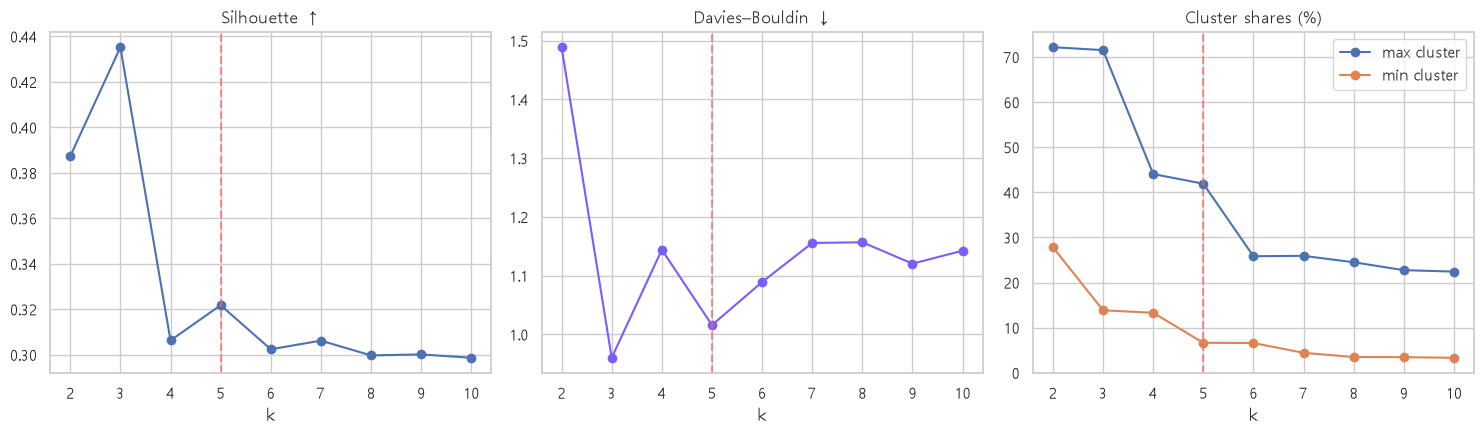

In [10]:
Xi, Xt, X_final, imputer, scaler, pca = cache['log_robust_pca90']
final_grid = kmeans_grid[kmeans_grid['method']=='log_robust_pca90'].copy()
display(final_grid[['k','silhouette','calinski_harabasz','davies_bouldin','min_share','max_share']])

fig, axes = plt.subplots(1,3,figsize=(15,4.5))
axes[0].plot(final_grid.k, final_grid.silhouette, marker='o'); axes[0].set_title('Silhouette ↑')
axes[1].plot(final_grid.k, final_grid.davies_bouldin, marker='o', color='#7C5CFC'); axes[1].set_title('Davies–Bouldin ↓')
axes[2].plot(final_grid.k, final_grid.max_share*100, marker='o', label='max cluster')
axes[2].plot(final_grid.k, final_grid.min_share*100, marker='o', label='min cluster')
axes[2].set_title('Cluster shares (%)'); axes[2].legend()
for ax in axes: ax.set_xlabel('k'); ax.axvline(5, ls='--', color='#EF6A6A', alpha=.7)
plt.tight_layout(); plt.show()

In [11]:
comparison_rows = []
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30, max_iter=500)
    lab = km.fit_predict(X_final)
    comparison_rows.append({'algorithm':'KMeans','k':k,'bic':np.nan,**cluster_metrics(X_final,lab)})
    for cov in ['diag','tied']:
        gm = GaussianMixture(n_components=k, covariance_type=cov, random_state=RANDOM_STATE,
                             n_init=3, reg_covar=1e-5, max_iter=400)
        lab = gm.fit_predict(X_final)
        comparison_rows.append({'algorithm':f'GMM-{cov}','k':k,'bic':gm.bic(X_final),
                                **cluster_metrics(X_final,lab)})
    br = Birch(n_clusters=k, threshold=.8)
    lab = br.fit_predict(X_final)
    comparison_rows.append({'algorithm':'Birch','k':k,'bic':np.nan,
                            **cluster_metrics(X_final,lab)})
model_comparison = pd.DataFrame(comparison_rows)
display(model_comparison.sort_values('silhouette', ascending=False).head(15))

,algorithm,k,bic,silhouette,calinski_harabasz,davies_bouldin,min_share,max_share
2,GMM-tied,3,176735.603088,0.442608,4063.523025,0.938430,0.111285,0.747374
0,KMeans,3,NaN,0.435256,4208.921975,0.960125,0.138436,0.715307
10,GMM-tied,5,166769.902218,0.420402,3000.709623,1.048632,0.032402,0.692402
3,Birch,3,NaN,0.381456,3250.105603,1.080433,0.131061,0.731955
1,GMM-diag,3,172823.669955,0.334100,2674.304548,1.470513,0.136089,0.601229
8,KMeans,5,NaN,0.321799,4055.437445,1.015817,0.066369,0.419106
14,GMM-tied,6,164866.761344,0.309325,3448.340024,1.053128,0.032067,0.455307
4,KMeans,4,NaN,0.306284,4072.534514,1.144100,0.132961,0.440559
16,KMeans,7,NaN,0.306209,3705.789526,1.155645,0.044134,0.259218
12,KMeans,6,NaN,0.302412,3795.937660,1.089115,0.065922,0.258324


**선택 논리**

- k=3은 실루엣이 가장 높지만 최대 군집이 약 72%라 마케팅 해상도가 낮습니다.
- GMM-tied는 분리도가 높아도 한 군집으로 69~75%가 몰립니다.
- k=5 k-means는 최대 41.9%, 최소 6.6%로 운영 가능한 크기이며 행동 프로파일이 명확합니다.
- 따라서 **수치 최적 k=3**과 **운영 최적 k=5**를 구분하고 최종안으로 k=5를 선택합니다.

## 5. 최종 모델과 안정성 검증

In [12]:
final_model = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=50, max_iter=500)
raw_cluster = final_model.fit_predict(X_final)
sil_each = silhouette_samples(X_final, raw_cluster)
final_metrics = cluster_metrics(X_final, raw_cluster)
print('PCA components:', pca.n_components_)
print('Explained variance:', pca.explained_variance_ratio_.sum())
print('Final metrics:', final_metrics)

rng = np.random.default_rng(RANDOM_STATE)
stability_ari = []
for seed in range(20):
    idx = rng.choice(len(X_final), size=int(.8*len(X_final)), replace=False)
    m = KMeans(n_clusters=5, n_init=20, random_state=seed, max_iter=500).fit(X_final[idx])
    stability_ari.append(adjusted_rand_score(raw_cluster, m.predict(X_final)))
print(f'Subsample ARI: mean={np.mean(stability_ari):.4f}, min={np.min(stability_ari):.4f}, max={np.max(stability_ari):.4f}')

PCA components: 6
Explained variance: 0.9066946184951022
Final metrics: {'silhouette': 0.32179881778864317, 'calinski_harabasz': 4055.4379539179095, 'davies_bouldin': 1.0160700569127115, 'min_share': np.float64(0.06636871508379888), 'max_share': np.float64(0.4187709497206704)}


Subsample ARI: mean=0.9947, min=0.9880, max=0.9980


## 6. 세그먼트 프로파일과 이름 부여

In [13]:
SEGMENT_MAP = {
    4: ('S1','우량 전액결제 헤비유저'),
    0: ('S2','생활결제 잔액유지형'),
    1: ('S3','현금서비스 의존형'),
    3: ('S4','신규·단기 현금서비스형'),
    2: ('S5','저활동 잠재휴면형'),
}
result = df.copy()
result['cluster_raw'] = raw_cluster
result['segment_code'] = [SEGMENT_MAP[x][0] for x in raw_cluster]
result['segment_name'] = [SEGMENT_MAP[x][1] for x in raw_cluster]
result['silhouette_sample'] = sil_each
distances = np.sort(final_model.transform(X_final), axis=1)
result['confidence_margin'] = (distances[:,1]-distances[:,0]) / np.maximum(distances[:,1], 1e-9)

order = ['S1','S2','S3','S4','S5']
profile_mean = result.groupby(['segment_code','segment_name'])[features].mean().reindex(order, level=0)
profile_median = result.groupby(['segment_code','segment_name'])[features].median().reindex(order, level=0)
sizes = result.groupby(['segment_code','segment_name']).size().rename('n').reindex(order, level=0)
summary = profile_mean[['BALANCE','PURCHASES','CASH_ADVANCE','PURCHASES_FREQUENCY',
                        'CASH_ADVANCE_FREQUENCY','CREDIT_LIMIT','PAYMENTS',
                        'PRC_FULL_PAYMENT','TENURE']].copy()
summary.insert(0, 'share', sizes/len(result))
summary.insert(0, 'n', sizes)
display(summary.round(3))

,,n,share,BALANCE,PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
segment_code,segment_name,,,,,,,,,,,
S1,우량 전액결제 헤비유저,1194,0.133,196.351,1963.200,107.671,0.805,0.016,5100.924,2169.884,0.821,11.563
S2,생활결제 잔액유지형,3748,0.419,1744.149,1522.041,510.474,0.714,0.071,4704.027,1811.272,0.048,11.928
S3,현금서비스 의존형,2300,0.257,2736.588,114.688,2275.173,0.085,0.315,4602.335,1859.654,0.022,11.857
S4,신규·단기 현금서비스형,594,0.066,1319.063,466.939,1689.086,0.409,0.258,2947.475,828.295,0.068,7.380
S5,저활동 잠재휴면형,1114,0.124,137.216,349.074,433.453,0.279,0.042,3740.756,1223.461,0.113,11.590


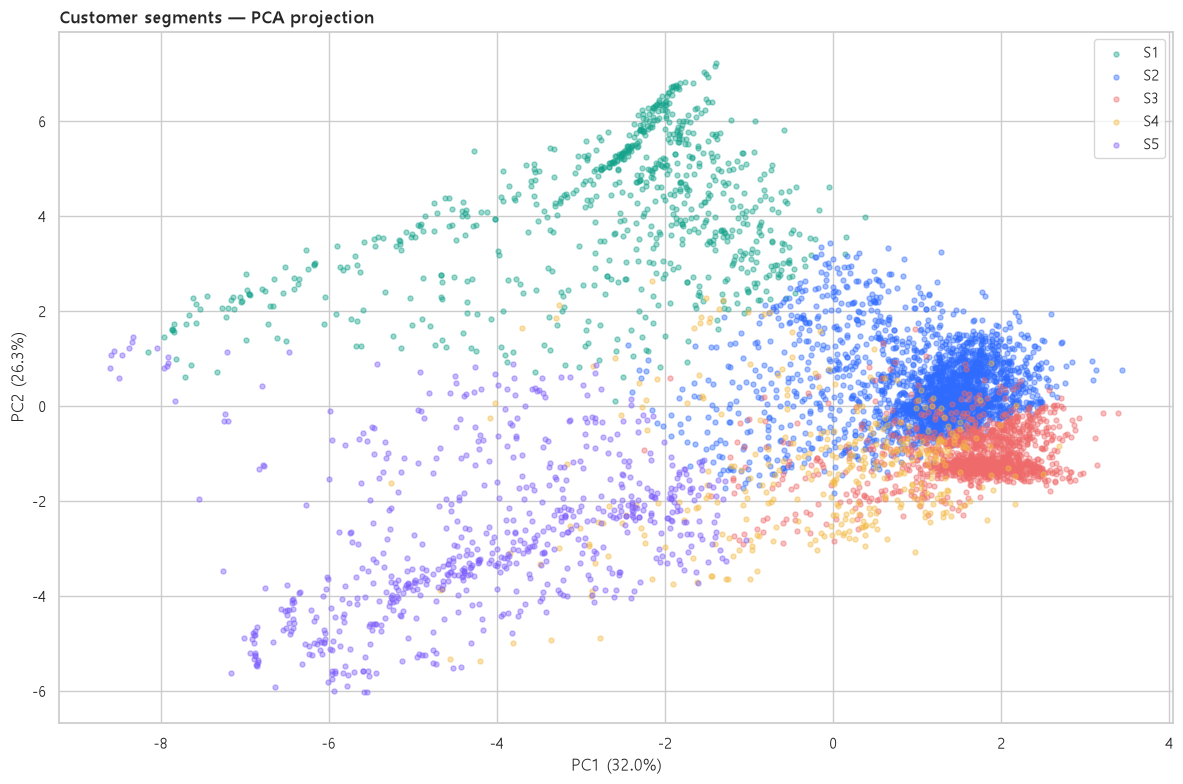

In [14]:
# 2D 시각화는 표현용이며 실제 학습은 6개 주성분 전체를 사용합니다.
colors = {'S1':'#15A38B','S2':'#2F6BFF','S3':'#EF6A6A','S4':'#F4B942','S5':'#7C5CFC'}
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_final), size=min(5500,len(X_final)), replace=False)
plt.figure(figsize=(12,8))
for code in order:
    use = idx[result.loc[idx,'segment_code'].values == code]
    plt.scatter(X_final[use,0], X_final[use,1], s=13, alpha=.42,
                c=colors[code], label=code)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Customer segments — PCA projection', loc='left', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

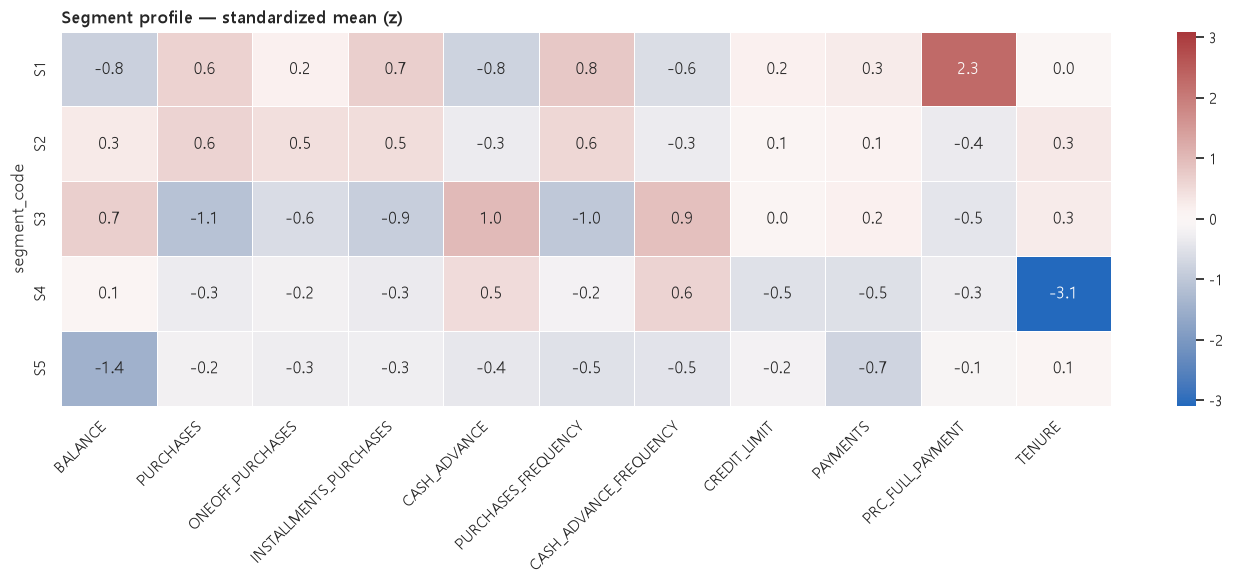

In [15]:
# 프로파일 비교 그림만 표준 z-score를 사용합니다. 모델 학습은 RobustScaler를 유지합니다.
scaled_df = pd.DataFrame(StandardScaler().fit_transform(Xt), columns=features)
scaled_df['segment_code'] = result['segment_code'].values
show_cols = ['BALANCE','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES',
             'CASH_ADVANCE','PURCHASES_FREQUENCY','CASH_ADVANCE_FREQUENCY',
             'CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT','TENURE']
hp = scaled_df.groupby('segment_code')[show_cols].mean().reindex(order)
vmax = max(1.0, np.nanmax(np.abs(hp.values)))
plt.figure(figsize=(14,6))
sns.heatmap(hp, cmap='vlag', center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.1f', linewidths=.5)
plt.title('Segment profile — standardized mean (z)', loc='left', fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

### 세그먼트 해석

- **S1 우량 전액결제 헤비유저:** 구매가 높고 잔액·현금서비스가 낮으며 전액결제 성향이 강함
- **S2 생활결제 잔액유지형:** 구매는 활발하지만 잔액을 유지하고 전액결제율이 낮은 최대 고객층
- **S3 현금서비스 의존형:** 구매는 거의 없고 현금서비스·잔액이 높음
- **S4 신규·단기 현금서비스형:** 보유기간이 짧고 초기부터 현금서비스 사용이 큼
- **S5 저활동 잠재휴면형:** 잔액과 구매 활동이 모두 낮음

## 7. 세그먼트별 마케팅 전략

In [16]:
strategy = pd.DataFrame([
    ['S1','주결제 카드화','프리미엄 리워드·여행/구독 제휴','증분 구매액·90일 유지율','혜택비용 상한'],
    ['S2','가치 유지+건전상환','자동납부·생활비 리워드·계획형 할부','자동납부 전환·연체 선행지표','부채 확대 카피 금지'],
    ['S3','현금서비스 의존 완화','저비용 상환 대안·금융건강 상담','현금서비스 비중 감소·정상상환','추가 현금서비스 업셀 금지'],
    ['S4','초기 위험 완화','30·60·90일 온보딩·결제일 알림','90일 정상상환·재사용률','경계 고객 수동 검토'],
    ['S5','저비용 재활성화','만료형 1회성 보너스','증분 활성률·ROI','통제군·접촉빈도 상한'],
], columns=['segment','objective','offer','primary_kpi','guardrail'])
display(strategy)

,segment,objective,offer,primary_kpi,guardrail
0,S1,주결제 카드화,프리미엄 리워드·여행/구독 제휴,증분 구매액·90일 유지율,혜택비용 상한
1,S2,가치 유지+건전상환,자동납부·생활비 리워드·계획형 할부,자동납부 전환·연체 선행지표,부채 확대 카피 금지
2,S3,현금서비스 의존 완화,저비용 상환 대안·금융건강 상담,현금서비스 비중 감소·정상상환,추가 현금서비스 업셀 금지
3,S4,초기 위험 완화,30·60·90일 온보딩·결제일 알림,90일 정상상환·재사용률,경계 고객 수동 검토
4,S5,저비용 재활성화,만료형 1회성 보너스,증분 활성률·ROI,통제군·접촉빈도 상한


## 8. 운영용 결과 내보내기

고객별 배정뿐 아니라 개별 실루엣과 중심 거리 마진을 함께 저장합니다. 경계 고객은 자동 개인화에서 제외할 수 있습니다. 모델 bundle은 새 고객에 동일 전처리와 중심을 적용하는 데 사용합니다.

In [17]:
output_dir = Path('/content') if Path('/content').exists() else Path('work/notebook_runtime')
output_dir.mkdir(parents=True, exist_ok=True)
result.to_csv(output_dir/'mission13_customer_segments.csv', index=False, encoding='utf-8-sig')
profile_mean.to_csv(output_dir/'mission13_segment_profile.csv', encoding='utf-8-sig')
bundle = {
    'feature_names': features,
    'log_columns': LOG_COLS,
    'imputer': imputer,
    'scaler': scaler,
    'pca': pca,
    'kmeans': final_model,
    'segment_map': SEGMENT_MAP,
    'random_state': RANDOM_STATE,
}
joblib.dump(bundle, output_dir/'mission13_model_bundle.joblib')
print('saved to:', output_dir.resolve())
display(result[['CUST_ID','segment_code','segment_name','silhouette_sample','confidence_margin']].head())

saved to: C:\Users\lucy5\Documents\Codex\2026-09-14\13-1-eda-2-k-means\work\notebook_runtime


,CUST_ID,segment_code,segment_name,silhouette_sample,confidence_margin
0,C10001,S2,생활결제 잔액유지형,0.079448,0.143856
1,C10002,S3,현금서비스 의존형,0.429853,0.529161
2,C10003,S2,생활결제 잔액유지형,0.327170,0.420451
3,C10004,S5,저활동 잠재휴면형,0.089876,0.218808
4,C10005,S3,현금서비스 의존형,0.087473,0.007556


## 9. 한계와 다음 단계

1. 비지도학습이므로 군집은 정답 클래스가 아닙니다. 실제 캠페인 반응 차이를 A/B 테스트로 검증해야 합니다.
2. 통화·집계기간·수익·연체·거래시점 정보가 없으므로 현재 결과는 행동 스냅샷 세분화입니다.
3. `TENURE`가 짧은 고객은 총액이 낮게 관측될 수 있어 운영 시 월평균 지표를 추가 검토합니다.
4. S3·S4에는 판매보다 소비자보호·상환안정 정책을 우선합니다.
5. 월별 PSI, 세그먼트 비중, 평균 실루엣을 모니터링하고 drift가 확인될 때 재학습합니다.